In [1]:
import os
import pandas as pd

print("Files in current dir:", os.listdir('.'))
if os.path.exists('amazon_reviews.csv'):
    df = pd.read_csv('amazon_reviews.csv')
    print("Columns:", df.columns)
    print("Shape:", df.shape)
    print(df.head())
else:
    print("amazon_reviews.csv not found directly, searching...")
    for root, dirs, files in os.walk('.'):
        for f in files:
            if 'amazon' in f.lower() or 'review' in f.lower():
                print(os.path.join(root, f))

Files in current dir: ['amazon_reviews.csv', 'HW1_Thanapoom_Sentiment_Analysis_with_Text_Classification.ipynb', '.DS_Store', 'Gemini.ipynb', 'create_notebook.py', 'Laukik.ipynb', 'Google.ipynb', 'HW-1.pdf']
Columns: Index(['overall', 'reviewText'], dtype='str')
Shape: (4915, 2)
   overall                                         reviewText
0        4                                         No issues.
1        5  Purchased this for my device, it worked as adv...
2        4  it works as expected. I should have sprung for...
3        5  This think has worked out great.Had a diff. br...
4        5  Bought it with Retail Packaging, arrived legit...


In [2]:
import sys
import sklearn
import numpy as np
import pandas as pd
import nltk
import matplotlib

print("Python version:", sys.version)
print("sklearn version:", sklearn.__version__)
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("nltk version:", nltk.__version__)
print("matplotlib version:", matplotlib.__version__)

try:
    import gensim
    print("gensim version:", gensim.__version__)
except ImportError:
    print("gensim not installed")

try:
    import torch
    print("torch version:", torch.__version__)
except ImportError:
    print("torch not installed")

Python version: 3.14.7 (v3.14.7:823f0323ee6, Aug  5 2026, 07:07:01) [Clang 21.0.0 (clang-2100.1.1.101)]
sklearn version: 1.9.1
numpy version: 2.5.3
pandas version: 3.0.6
nltk version: 3.10.3
matplotlib version: 3.11.2
gensim not installed
torch not installed


In [3]:
df = pd.read_csv('amazon_reviews.csv')
print(df.info())
print("\nOverall rating counts:")
print(df['overall'].value_counts().sort_index())
print("\nNull values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   overall     4915 non-null   int64
 1   reviewText  4914 non-null   str  
dtypes: int64(1), str(1)
memory usage: 76.9 KB
None

Overall rating counts:
overall
1     244
2      80
3     142
4     527
5    3922
Name: count, dtype: int64

Null values:
overall       0
reviewText    1
dtype: int64


In [4]:
null_row = df[df['reviewText'].isnull()]
print(null_row)

     overall reviewText
125        5        NaN


In [5]:
import re
import nltk
from nltk.corpus import stopwords
import string

try:
    nltk.download('stopwords', quiet=True)
    stop_words = set(stopwords.words('english'))
except Exception as e:
    print(e)
    stop_words = set()

print(f"Loaded {len(stop_words)} stopwords")

# Let's test preprocessing on a small subset
def preprocess_text(text):
    if not isinstance(text, str):
        return []
    # (i) lowercase
    text = text.lower()
    # (ii) remove punctuations and numbers
    text = re.sub(r'[^a-z\s]', ' ', text)
    # (iii) tokenize and remove stopwords
    tokens = [w for w in text.split() if w not in stop_words]
    return tokens

clean_df = df.dropna(subset=['reviewText']).copy()
clean_df['tokens'] = clean_df['reviewText'].apply(preprocess_text)
corpus = clean_df['tokens'].tolist()

all_words = set()
for doc in corpus:
    all_words.update(doc)
print(f"Total distinct words in raw corpus: {len(all_words)}")


**********************************************************************
  Resource 'stopwords' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('stopwords')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'corpora/stopwords'

  Searched in:
    - '/Users/mandarbavdane/nltk_data'
    - '/Library/Frameworks/Python.framework/Versions/3.14/nltk_data'
    - '/Library/Frameworks/Python.framework/Versions/3.14/share/nltk_data'
    - '/Library/Frameworks/Python.framework/Versions/3.14/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************

Loaded 0 stopwords
Total distinct words in raw corpus: 7645


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1082)>


In [6]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
print(f"sklearn stopwords: {len(ENGLISH_STOP_WORDS)}")

# Let's test with sklearn ENGLISH_STOP_WORDS or nltk stopwords
stop_words = set(ENGLISH_STOP_WORDS)
clean_df['tokens'] = clean_df['reviewText'].apply(preprocess_text)
corpus = clean_df['tokens'].tolist()
all_words = set(w for doc in corpus for w in doc)
print(f"Total distinct words in raw corpus: {len(all_words)}")

sklearn stopwords: 318
Total distinct words in raw corpus: 7362


In [7]:
import time

def get_vacab(corpus):
    """
    Returns corpus_words, which is the list of all distinct words in the corpus, sorted.
    """
    corpus_words = sorted(list(set(word for review in corpus for word in review)))
    return corpus_words

get_vocab = get_vacab

t0 = time.time()
vocab = get_vacab(corpus)
print(f"Vocab size: {len(vocab)}, computed in {time.time()-t0:.2f}s")

def compute_co_occurrence_matrix(corpus, window_size=4):
    """
    Constructs co-occurrence matrix M and word2index mapping.
    """
    corpus_words = get_vacab(corpus)
    num_words = len(corpus_words)
    word2index = {word: idx for idx, word in enumerate(corpus_words)}
    M = np.zeros((num_words, num_words), dtype=np.float32)
    
    for review in corpus:
        review_len = len(review)
        for i, center_word in enumerate(review):
            if center_word not in word2index:
                continue
            center_idx = word2index[center_word]
            start = max(0, i - window_size)
            end = min(review_len, i + window_size + 1)
            for j in range(start, end):
                if i != j:
                    context_word = review[j]
                    if context_word in word2index:
                        context_idx = word2index[context_word]
                        M[center_idx, context_idx] += 1.0
    return M, word2index

t0 = time.time()
M, word2index = compute_co_occurrence_matrix(corpus, window_size=4)
print(f"Co-occurrence matrix shape: {M.shape}, computed in {time.time()-t0:.2f}s")

Vocab size: 7362, computed in 0.01s


Co-occurrence matrix shape: (7362, 7362), computed in 0.26s


In [8]:
import time

def get_vacab(corpus):
    """
    Returns corpus_words, which is the list of all distinct words in the corpus, sorted.
    """
    corpus_words = sorted(list(set(word for review in corpus for word in review)))
    return corpus_words

get_vocab = get_vacab

t0 = time.time()
vocab = get_vacab(corpus)
print(f"Vocab size: {len(vocab)}, computed in {time.time()-t0:.2f}s")

def compute_co_occurrence_matrix(corpus, window_size=4):
    """
    Constructs co-occurrence matrix M and word2index mapping.
    """
    corpus_words = get_vacab(corpus)
    num_words = len(corpus_words)
    word2index = {word: idx for idx, word in enumerate(corpus_words)}
    M = np.zeros((num_words, num_words), dtype=np.float32)
    
    for review in corpus:
        review_len = len(review)
        for i, center_word in enumerate(review):
            if center_word not in word2index:
                continue
            center_idx = word2index[center_word]
            start = max(0, i - window_size)
            end = min(review_len, i + window_size + 1)
            for j in range(start, end):
                if i != j:
                    context_word = review[j]
                    if context_word in word2index:
                        context_idx = word2index[context_word]
                        M[center_idx, context_idx] += 1.0
    return M, word2index

t0 = time.time()
M, word2index = compute_co_occurrence_matrix(corpus, window_size=4)
print(f"Co-occurrence matrix shape: {M.shape}, computed in {time.time()-t0:.2f}s")

Vocab size: 7362, computed in 0.01s
Co-occurrence matrix shape: (7362, 7362), computed in 0.24s


In [9]:
from sklearn.decomposition import TruncatedSVD

try:
    svd = TruncatedSVD(n_components=2, n_iters=10)
    print("n_iters accepted!")
except TypeError as e:
    print("TypeError with n_iters:", e)

svd = TruncatedSVD(n_components=2, n_iter=10, random_state=42)
print("n_iter works:", svd)

TypeError with n_iters: TruncatedSVD.__init__() got an unexpected keyword argument 'n_iters'. Did you mean 'n_iter'?
n_iter works: TruncatedSVD(n_iter=10, random_state=42)


In [10]:
words_to_plot = ['purchase', 'buy', 'work', 'got', 'ordered', 'received', 'product', 'item', 'deal', 'use']
for w in words_to_plot:
    print(w, w in word2index)

purchase True
buy True
work True
got True
ordered True
received True
product True
item True
deal True
use True


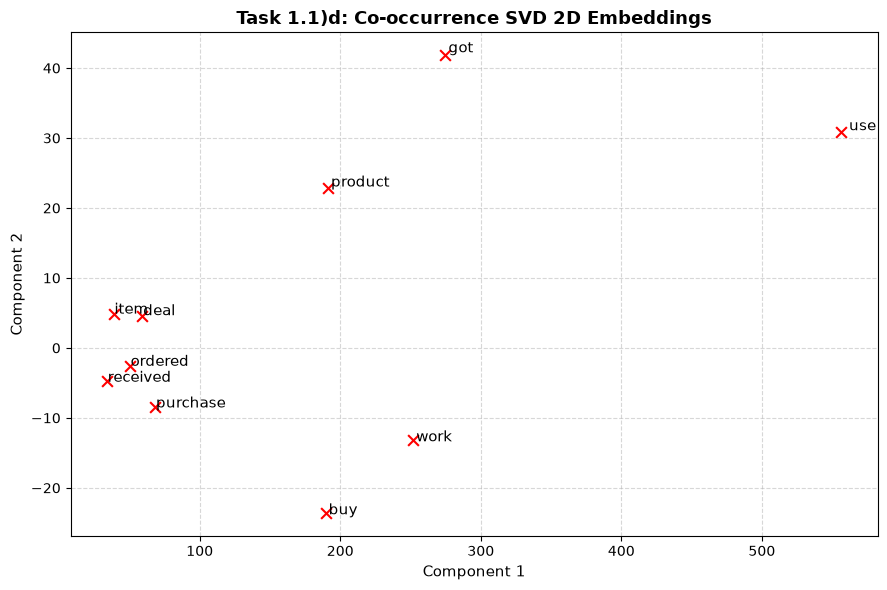

In [11]:
import matplotlib.pyplot as plt

def reduce_to_k_dim(M, k=2):
    """
    Performs dimensionality reduction on matrix M using TruncatedSVD to produce k-dimensional embeddings.
    """
    svd = TruncatedSVD(n_components=k, n_iter=10, random_state=42)
    M_reduced = svd.fit_transform(M)
    return M_reduced

M_reduced_2d = reduce_to_k_dim(M, k=2)

def plot_embeddings(M_reduced, word2index, words_to_plot, title="Word Embeddings (2D Truncated SVD)"):
    """
    Scatterplot of 2D embeddings for the specified words in words_to_plot.
    """
    plt.figure(figsize=(9, 6))
    for word in words_to_plot:
        if word in word2index:
            idx = word2index[word]
            x = M_reduced[idx, 0]
            y = M_reduced[idx, 1]
            plt.scatter(x, y, marker='x', color='red', s=60)
            plt.text(x + 0.01 * (x if x != 0 else 1), y + 0.01 * (y if y != 0 else 1), word, fontsize=11)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel("Component 1", fontsize=11)
    plt.ylabel("Component 2", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Test plot
plot_embeddings(M_reduced_2d, word2index, words_to_plot, title="Task 1.1)d: Co-occurrence SVD 2D Embeddings")

In [12]:
# Let's test the entire pipeline on the dataset with the co-occurrence embeddings reduced to 128-dim,
# and also test the classification pipeline.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Filter dataset: remove rating 3, map 1-2 to 0, 4-5 to 1
clean_df = df.dropna(subset=['reviewText']).copy()
binary_df = clean_df[clean_df['overall'] != 3].copy()
binary_df['label'] = binary_df['overall'].apply(lambda r: 1 if r >= 4 else 0)

print(f"Total binary samples: {len(binary_df)}")
print(f"Label distribution:\n{binary_df['label'].value_counts()}")

# Data split: 80% train, 10% val, 10% test
train_df, temp_df = train_test_split(binary_df, test_size=0.2, random_state=42, stratify=binary_df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"Train size: {len(train_df)}, Val size: {len(val_df)}, Test size: {len(test_df)}")

Total binary samples: 4772
Label distribution:
label
1    4448
0     324
Name: count, dtype: int64
Train size: 3817, Val size: 477, Test size: 478
